In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
results = pd.DataFrame({

    "Model":[

        "Random Forest v6",

        "XGBoost Baseline",

        "XGBoost Tuning v1",

        "XGBoost Tuning v2",

        "XGBoost Tuning v3",

        "LightGBM Baseline",

        "LightGBM Tuning v1"

    ],

    "Accuracy":[

        0.6408,

        0.6800,

        0.6697,

        0.6907,

        0.6813,

        0.6753,

        0.6729

    ],

    "Aggressive Recall":[

        0.76,

        0.82,

        0.82,

        0.83,

        0.83,

        0.85,

        0.84

    ],

    "Drowsy Recall":[

        0.54,

        0.56,

        0.54,

        0.55,

        0.55,

        0.53,

        0.54

    ],

    "Drowsy Precision":[

        0.84,

        0.89,

        0.89,

        0.92,

        0.90,

        0.89,

        0.89

    ],

    "Normal Recall":[

        0.77,

        0.84,

        0.84,

        0.89,

        0.86,

        0.84,

        0.84

    ]

})

results

,Model,Accuracy,Aggressive Recall,Drowsy Recall,Drowsy Precision,Normal Recall
0,Random Forest v6,0.6408,0.76,0.54,0.84,0.77
1,XGBoost Baseline,0.6800,0.82,0.56,0.89,0.84
2,XGBoost Tuning v1,0.6697,0.82,0.54,0.89,0.84
3,XGBoost Tuning v2,0.6907,0.83,0.55,0.92,0.89
4,XGBoost Tuning v3,0.6813,0.83,0.55,0.90,0.86
5,LightGBM Baseline,0.6753,0.85,0.53,0.89,0.84
6,LightGBM Tuning v1,0.6729,0.84,0.54,0.89,0.84


In [4]:
results.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy,Aggressive Recall,Drowsy Recall,Drowsy Precision,Normal Recall
3,XGBoost Tuning v2,0.6907,0.83,0.55,0.92,0.89
4,XGBoost Tuning v3,0.6813,0.83,0.55,0.90,0.86
1,XGBoost Baseline,0.6800,0.82,0.56,0.89,0.84
5,LightGBM Baseline,0.6753,0.85,0.53,0.89,0.84
6,LightGBM Tuning v1,0.6729,0.84,0.54,0.89,0.84
2,XGBoost Tuning v1,0.6697,0.82,0.54,0.89,0.84
0,Random Forest v6,0.6408,0.76,0.54,0.84,0.77


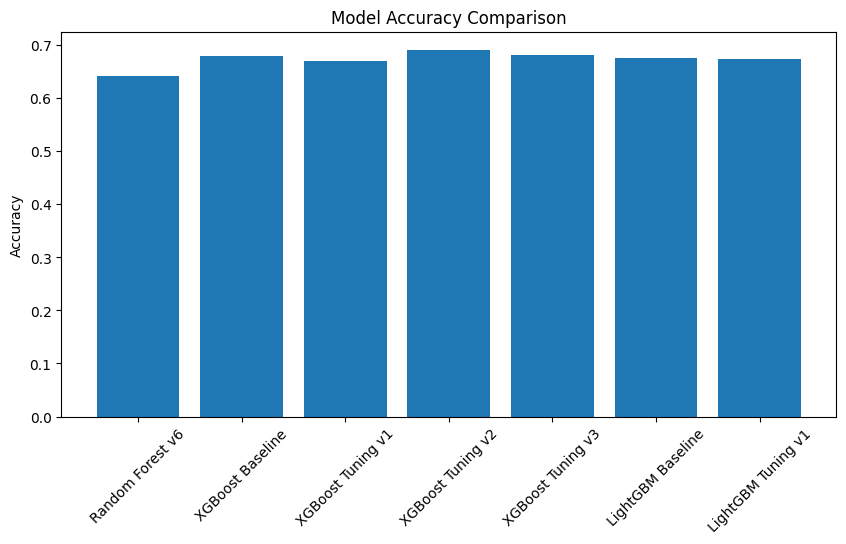

In [5]:
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

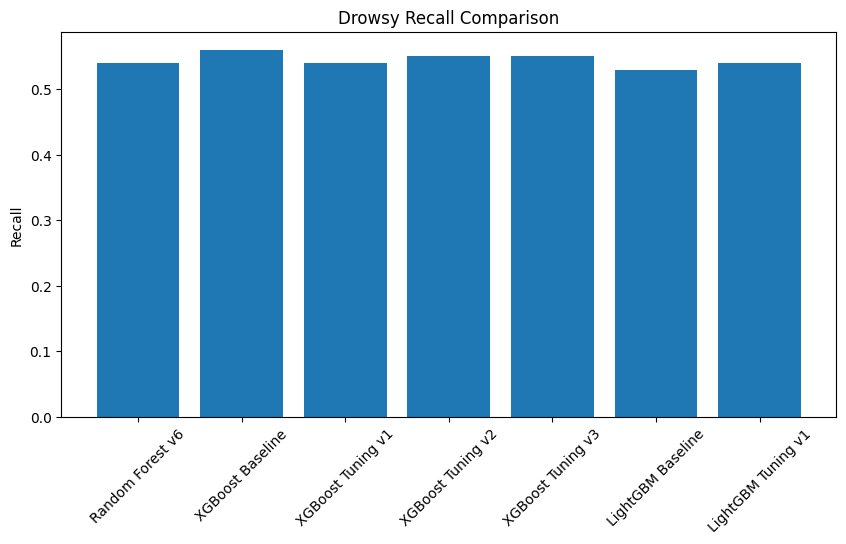

In [6]:
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Drowsy Recall"]
)

plt.xticks(rotation=45)

plt.ylabel("Recall")

plt.title("Drowsy Recall Comparison")

plt.show()

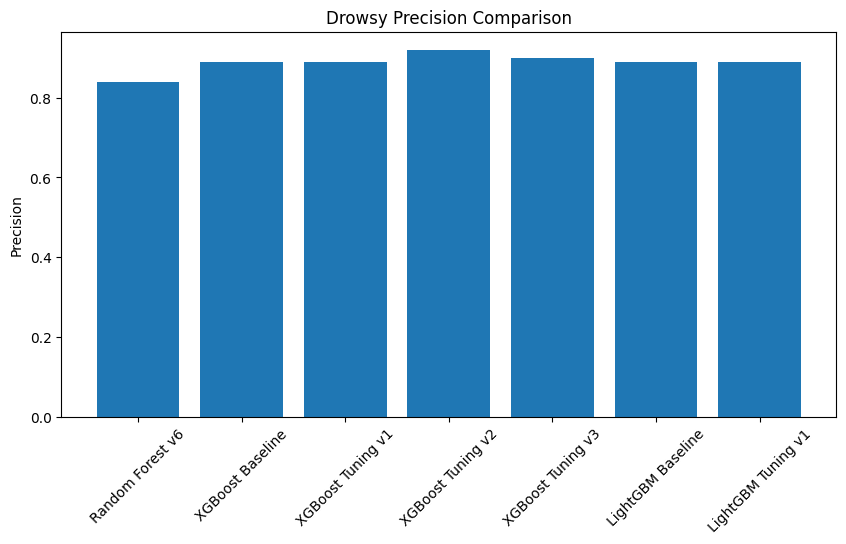

In [7]:
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Drowsy Precision"]
)

plt.xticks(rotation=45)

plt.ylabel("Precision")

plt.title("Drowsy Precision Comparison")

plt.show()

In [8]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

best_model

,3
Model,XGBoost Tuning v2
Accuracy,0.6907
Aggressive Recall,0.83
Drowsy Recall,0.55
Drowsy Precision,0.92
Normal Recall,0.89


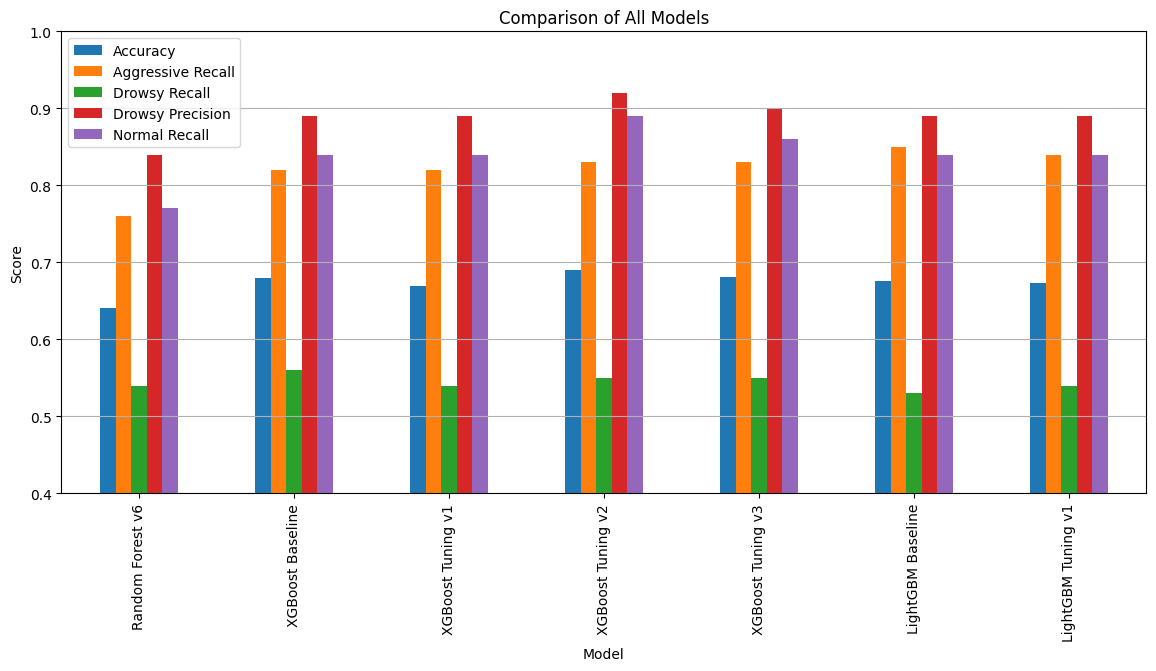

In [10]:
metrics = results.set_index("Model")[
    [
        "Accuracy",
        "Aggressive Recall",
        "Drowsy Recall",
        "Drowsy Precision",
        "Normal Recall"
    ]
]

metrics.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Comparison of All Models")

plt.ylabel("Score")

plt.ylim(0.4,1.0)

plt.grid(axis="y")

plt.show()

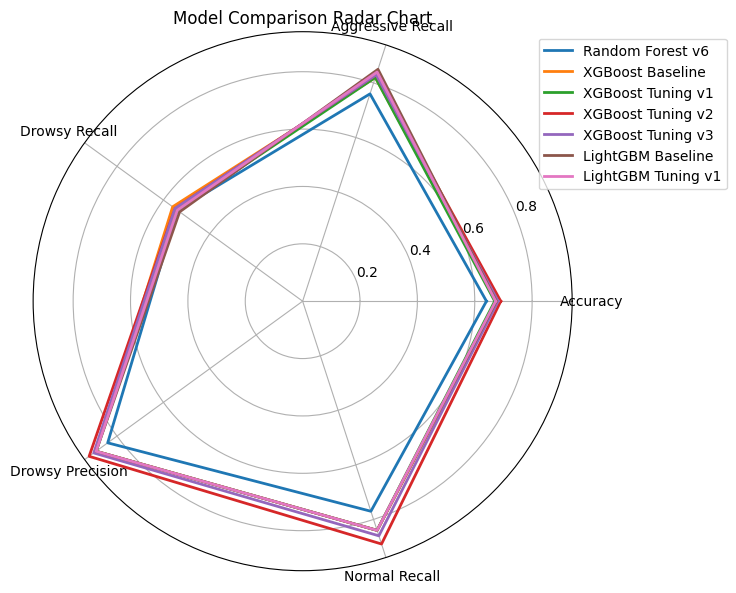

In [11]:
import numpy as np

metrics = [
    "Accuracy",
    "Aggressive Recall",
    "Drowsy Recall",
    "Drowsy Precision",
    "Normal Recall"
]

labels = np.array(metrics)

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
)

angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure(figsize=(7,7))

ax = plt.subplot(111, polar=True)

for _, row in results.iterrows():

    values = row[metrics].values

    values = np.concatenate((values,[values[0]]))

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(labels)

plt.legend(
    bbox_to_anchor=(1.3,1)
)

plt.title("Model Comparison Radar Chart")

plt.show()

In [12]:
results.to_csv(

    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/results/model_comparison.csv",

    index=False

)

print("Results saved successfully.")

Results saved successfully.


In [14]:
best_accuracy = results.loc[
    results["Accuracy"].idxmax()
]

best_accuracy

,3
Model,XGBoost Tuning v2
Accuracy,0.6907
Aggressive Recall,0.83
Drowsy Recall,0.55
Drowsy Precision,0.92
Normal Recall,0.89


In [16]:
best_drowsy = results.loc[
    results["Drowsy Recall"].idxmax()
]

best_drowsy

,1
Model,XGBoost Baseline
Accuracy,0.68
Aggressive Recall,0.82
Drowsy Recall,0.56
Drowsy Precision,0.89
Normal Recall,0.84


In [17]:
print("="*60)

print("FINAL MODEL SELECTION")

print("="*60)

print()

print(
    "Best Accuracy :",
    best_accuracy["Model"],
    f"({best_accuracy['Accuracy']:.4f})"
)

print()

print(
    "Best Drowsy Recall :",
    best_drowsy["Model"],
    f"({best_drowsy['Drowsy Recall']:.2f})"
)

FINAL MODEL SELECTION

Best Accuracy : XGBoost Tuning v2 (0.6907)

Best Drowsy Recall : XGBoost Baseline (0.56)


# Final Discussion

A total of seven model configurations were evaluated.

Random Forest served as the baseline model.

XGBoost significantly improved overall classification performance.

Hyperparameter tuning further increased the overall accuracy to **69.07%**.

Although XGBoost Baseline achieved the highest Drowsy Recall, XGBoost Tuning v2 provided the best balance between overall accuracy and precision.

LightGBM produced competitive results but did not surpass XGBoost.

Therefore, **XGBoost Tuning v2** was selected as the final model for driver behavior classification.